In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 12
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

font_path = os.path.join('..', 'other', 'Roboto', 'Roboto-Regular.ttf')
font_prop = FontProperties(fname = font_path)
fm.fontManager.addfont(font_path)
custom_font_name = font_prop.get_name()

font_path_bold = os.path.join('..', 'other', 'Roboto', 'Roboto-Bold.ttf')
font_prop_bold = FontProperties(fname = font_path_bold)

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = custom_font_name
plt.rcParams['axes.unicode_minus'] = True

In [3]:
economics_results_file = 'vcm_production_costs.xlsx'
climate_change_results_file = 'vcm_climate_change_impact.xlsx'

In [4]:
economics_df = pd.read_excel(os.path.join('..', 'results', economics_results_file), sheet_name = 'overall', index_col = 0)
economics_df_final = economics_df.drop(columns = ['Total','Low', 'High'])
economics_df_final

,Scenario,Acetylene,Ethylene,Chlorine or HCl,Electricity,Heating utilities,Cooling utilities,Direct emissions
0,ATV,0.490464,0.000000,0.089352,0.000000,0.000232,0.010916,0
1,EBP,0.000000,0.801669,0.221949,0.002281,0.014378,0.102399,0
2,ATV,0.646048,0.000000,0.089352,0.000000,0.000232,0.010916,0
3,EBP,0.000000,1.986677,0.221949,0.002281,0.014378,0.102399,0


In [5]:
climate_change_df = pd.read_excel(os.path.join('..', 'results', climate_change_results_file), sheet_name = 'overall', index_col = 0)
climate_change_df_final = climate_change_df.drop(columns =  ['Total', 'STDEV', 'Low', 'High'])
climate_change_df_final

,Scenario,Acetylene,Ethylene,Chlorine or HCl,Electricity,Heating utilities,Cooling utilities,Direct emissions
0,ATV,5.387136,0.000000,0.169977,0.000000,0.002710,0.091716,0.000
1,EBP,0.000000,1.110495,0.588774,0.016299,0.169762,0.444601,0.018
2,ATV,1.412812,0.000000,0.169977,0.000000,0.002710,0.091716,0.000
3,EBP,0.000000,-0.453000,0.588774,0.016299,0.169762,0.444601,0.018


In [6]:
x_pts = np.arange(0, len(climate_change_df_final))
x_labels = []
for i in range(0, len(x_pts)):
    string = climate_change_df_final['Scenario'][i]
    new = '\n'
    string = new.join(string.rsplit(' ', 1))
    x_labels.append(string)
x_labels

['ATV', 'EBP', 'ATV', 'EBP']

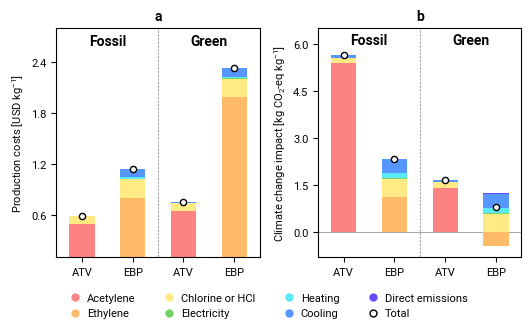

In [7]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[1.5], fig_height*0.3))

colors = ['#FD8383', '#FFBB68', '#FFEA83', '#75D462', '#5AE9F6', '#5596FF', '#674CFF'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax2.set_title('b', fontproperties = font_prop_bold)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([-0.8, 6.5])
ax2.text(0.5, 6.0, 'Fossil', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax2.text(2.5, 6.0, 'Green', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax2.yaxis.set_major_locator(MaxNLocator(5))
# ax1.set_xticks([])

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs [USD kg$^\mathdefault{-1}$]')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax1.set_title('a', fontproperties = font_prop_bold)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.set_ylim([0.1, 2.8])
ax1.text(0.5, 2.6, 'Fossil', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.text(2.5, 2.6, 'Green', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.yaxis.set_major_locator(MaxNLocator(5))

labels = ['Acetylene', 'Ethylene', 'Chlorine or HCl', 'Electricity', 'Heating', 'Cooling', 'Direct emissions', 'Total']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'vcm_main_figure')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

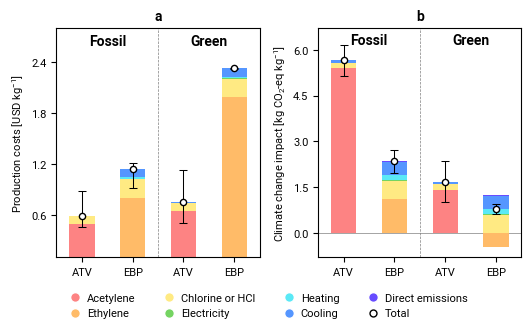

In [8]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[1.5], fig_height*0.3))

colors = ['#FD8383', '#FFBB68', '#FFEA83', '#75D462', '#5AE9F6', '#5596FF', '#674CFF'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax2.set_title('b', fontproperties = font_prop_bold)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.errorbar(x_pts, climate_change_df['Total'], yerr = 2 * climate_change_df['STDEV'], fmt = 'none', ecolor = '#000000', elinewidth = 0.75, capsize = 3, capthick = 0.75, zorder = 1)
ax2.set_ylim([-0.8, 6.7])
ax2.text(0.5, 6.2, 'Fossil', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax2.text(2.5, 6.2, 'Green', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax2.yaxis.set_major_locator(MaxNLocator(5))
# ax1.set_xticks([])

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs [USD kg$^\mathdefault{-1}$]')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax1.set_title('a', fontproperties = font_prop_bold)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.errorbar(
    x_pts,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax1.set_ylim([0.1, 2.8])
ax1.text(0.5, 2.6, 'Fossil', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.text(2.5, 2.6, 'Green', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.yaxis.set_major_locator(MaxNLocator(5))

labels = ['Acetylene', 'Ethylene', 'Chlorine or HCl', 'Electricity', 'Heating', 'Cooling', 'Direct emissions', 'Total']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'vcm_main_figure_with_eb')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)